# EUR/USD Mean Reversion Strategy
### Spot FX vs 6E Futures Backtest

This notebook compares a simple Bollinger Band + slope mean reversion strategy on:
- EUR/USD spot FX (IBKR)
- 6E CME Futures

### Loading Spot EUR/USD Data

In [7]:
import pandas as pd

df_spot = pd.read_csv("data/EURUSD_IBKR.csv", parse_dates=["date"])
df_spot.set_index("date", inplace=True)
df_spot.head()


,open,high,low,close,volume,average,barCount
date,,,,,,,
2005-05-30,1.2536,1.25460,1.2466,1.24760,-1.0,-1.0,-1
2005-05-31,1.2476,1.24870,1.2296,1.23030,-1.0,-1.0,-1
2005-06-01,1.2308,1.23410,1.2159,1.21790,-1.0,-1.0,-1
2005-06-02,1.2205,1.22975,1.2182,1.22660,-1.0,-1.0,-1
2005-06-03,1.2275,1.23430,1.2205,1.22345,-1.0,-1.0,-1


### Applying Mean Reversion Strategy

In [10]:
from strategies.mean_reversion import apply_mean_reversion_strategy

df_spot = apply_mean_reversion_strategy(df_spot, window=8, slope_window=3)


### Simulate Trades

In [13]:
from utils.backtest_engine import simulate_trades

df_spot = simulate_trades(df_spot)


### Plot Signal Chart (Spot)

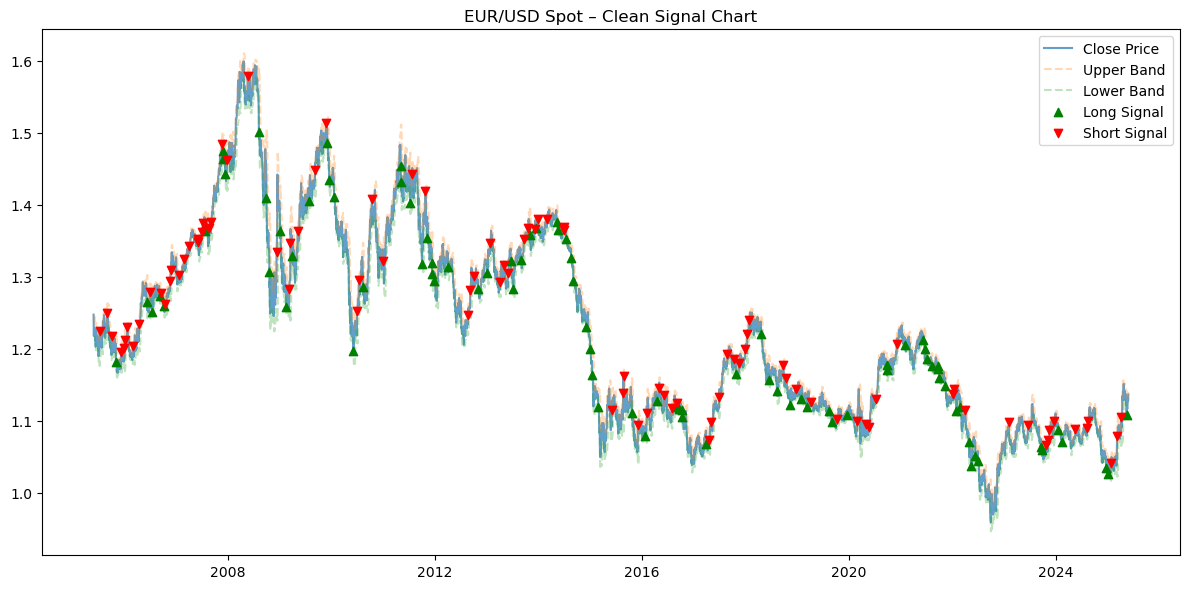

In [16]:
import matplotlib.pyplot as plt

def plot_signals(df, title):
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['close'], label='Close Price', alpha=0.7)
    plt.plot(df.index, df['upper'], linestyle='--', alpha=0.3, label='Upper Band')
    plt.plot(df.index, df['lower'], linestyle='--', alpha=0.3, label='Lower Band')
    plt.scatter(df[df['signal'] == 1].index, df[df['signal'] == 1]['close'],
                marker='^', color='green', label='Long Signal', zorder=3)
    plt.scatter(df[df['signal'] == -1].index, df[df['signal'] == -1]['close'],
                marker='v', color='red', label='Short Signal', zorder=3)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_signals(df_spot, "EUR/USD Spot – Clean Signal Chart")


### Display performance metrics (SPOT)

In [18]:

long_signals = df_spot[df_spot['signal'] == 1].shape[0]
short_signals = df_spot[df_spot['signal'] == -1].shape[0]

total_return = df_spot['equity'].iloc[-1] - 100
cagr = (df_spot['equity'].iloc[-1] / 100) ** (1 / (len(df_spot) / 252)) - 1
sharpe = df_spot['strategy_returns'].mean() / df_spot['strategy_returns'].std() * (252**0.5)
max_dd = (df_spot['equity'].cummax() - df_spot['equity']).max()

print(f"📉 EUR/USD Spot Strategy Performance:")
print(f"• Long signals: {long_signals}")
print(f"• Short signals: {short_signals}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• CAGR: {cagr:.2%}")
print(f"• Sharpe Ratio: {sharpe:.2f}")
print(f"• Max Drawdown: {max_dd:.2f}%")


📉 EUR/USD Spot Strategy Performance:
• Long signals: 89
• Short signals: 95
• Total Return: -8.72%
• CAGR: -0.44%
• Sharpe Ratio: -0.29
• Max Drawdown: 15.66%


### Plot Equity Curve (Spot)

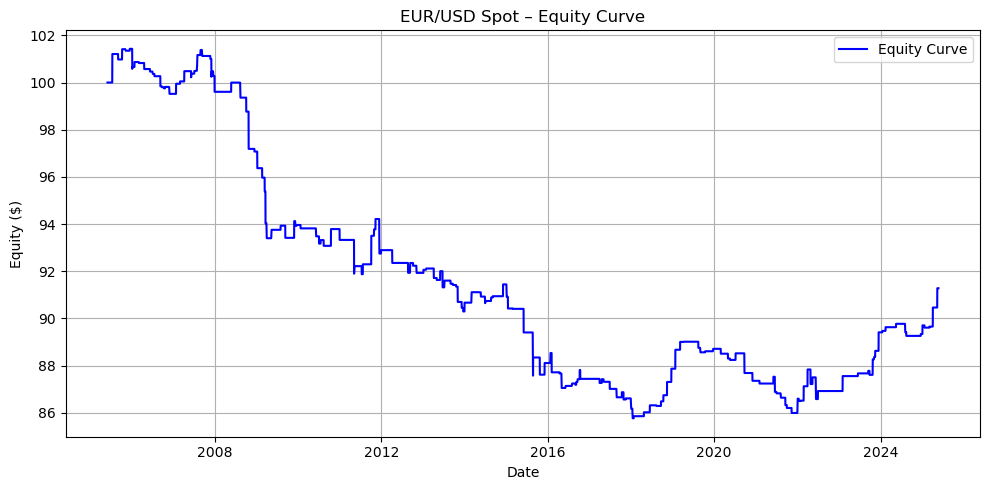

In [20]:
def plot_equity_curve(df, title):
    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df['equity'], label='Equity Curve', color='blue')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity ($)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_equity_curve(df_spot, "EUR/USD Spot – Equity Curve")



### Monthly Heatmap of Strategy Returns (EUR/USD Spot)

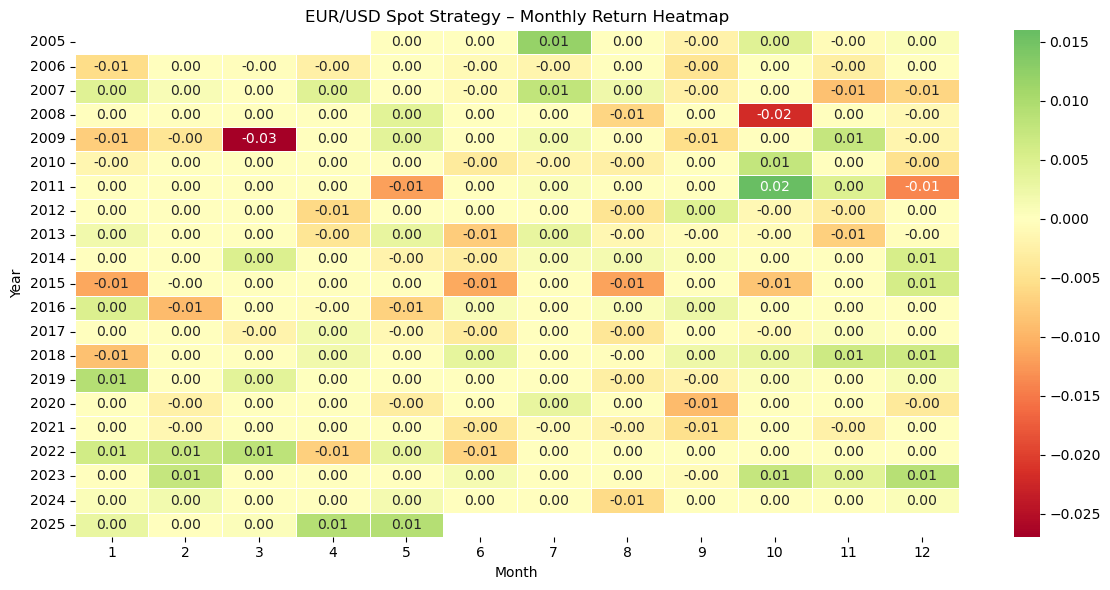

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare monthly return heatmap
df_spot['year'] = df_spot.index.year
df_spot['month'] = df_spot.index.month
df_spot['monthly_return'] = df_spot['strategy_returns']

# Group by year and month, sum monthly returns
monthly_heatmap = df_spot.groupby(['year', 'month'])['monthly_return'].sum().unstack()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(monthly_heatmap, cmap="RdYlGn", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("EUR/USD Spot Strategy – Monthly Return Heatmap")
plt.ylabel("Year")
plt.xlabel("Month")
plt.tight_layout()
plt.show()


### Load & Prepare 6E Data

In [27]:
import pandas as pd

# Load 6E continuous front-month futures data
df_6e = pd.read_csv("data/6E_proxy.csv", parse_dates=["date"])
df_6e.set_index("date", inplace=True)

# Apply same strategy
from strategies.mean_reversion import apply_mean_reversion_strategy
df_6e = apply_mean_reversion_strategy(df_6e, window=8, slope_window=3)

# Simulate trades
from utils.backtest_engine import simulate_trades
df_6e = simulate_trades(df_6e)


### Plot 6E Signal Chart

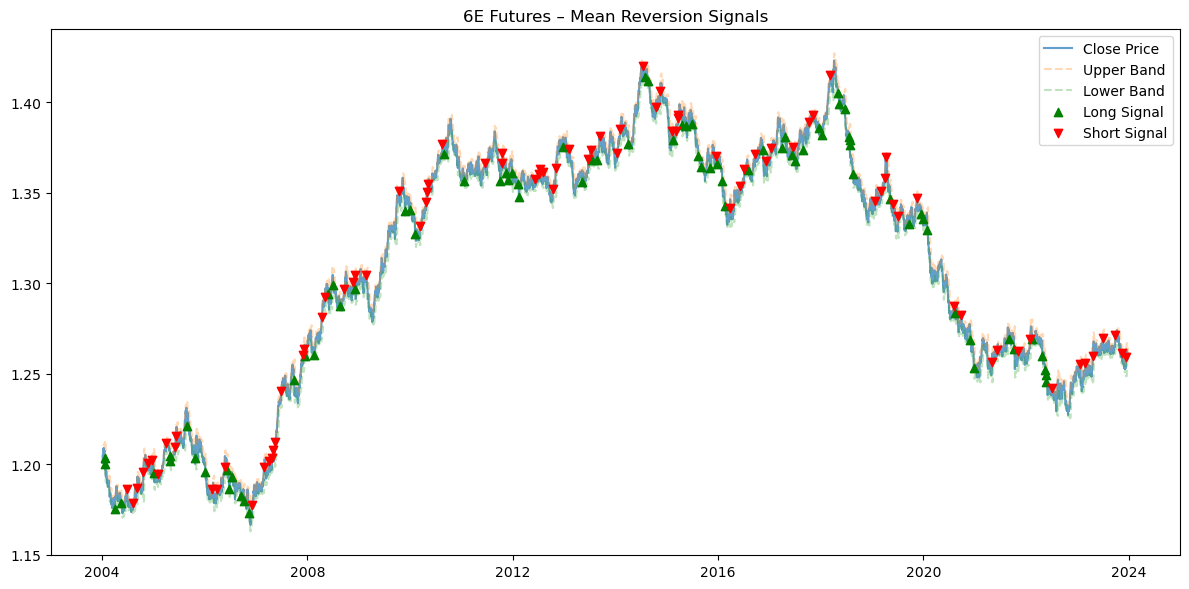

In [31]:
import matplotlib.pyplot as plt

def plot_signals(df, title):
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['close'], label='Close Price', alpha=0.7)
    plt.plot(df.index, df['upper'], linestyle='--', alpha=0.3, label='Upper Band')
    plt.plot(df.index, df['lower'], linestyle='--', alpha=0.3, label='Lower Band')
    plt.scatter(df[df['signal'] == 1].index, df[df['signal'] == 1]['close'],
                marker='^', color='green', label='Long Signal', zorder=3)
    plt.scatter(df[df['signal'] == -1].index, df[df['signal'] == -1]['close'],
                marker='v', color='red', label='Short Signal', zorder=3)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_signals(df_6e, "6E Futures – Mean Reversion Signals")



### Print Performance Metrics (6E)

In [34]:
# Metrics
long_signals = df_6e[df_6e['signal'] == 1].shape[0]
short_signals = df_6e[df_6e['signal'] == -1].shape[0]

total_return = df_6e['equity'].iloc[-1] - 100
cagr = (df_6e['equity'].iloc[-1] / 100) ** (1 / (len(df_6e) / 252)) - 1
sharpe = df_6e['strategy_returns'].mean() / df_6e['strategy_returns'].std() * (252**0.5)
max_dd = (df_6e['equity'].cummax() - df_6e['equity']).max()

print(f"📉 6E Futures Strategy Performance:")
print(f"• Long signals: {long_signals}")
print(f"• Short signals: {short_signals}")
print(f"• Total Return: {total_return:.2f}%")
print(f"• CAGR: {cagr:.2%}")
print(f"• Sharpe Ratio: {sharpe:.2f}")
print(f"• Max Drawdown: {max_dd:.2f}%")


📉 6E Futures Strategy Performance:
• Long signals: 82
• Short signals: 88
• Total Return: 0.32%
• CAGR: 0.02%
• Sharpe Ratio: 0.04
• Max Drawdown: 1.69%


### Equity Curve (6E)

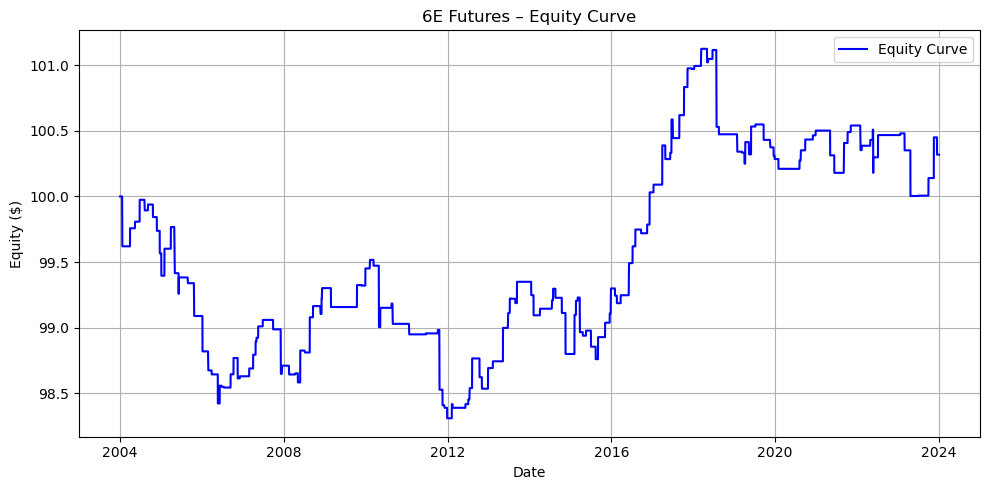

In [37]:
def plot_equity_curve(df, title):
    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df['equity'], label='Equity Curve', color='blue')
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Equity ($)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_equity_curve(df_6e, "6E Futures – Equity Curve")


### Monthly Heatmap of Strategy Returns (6E Futures)

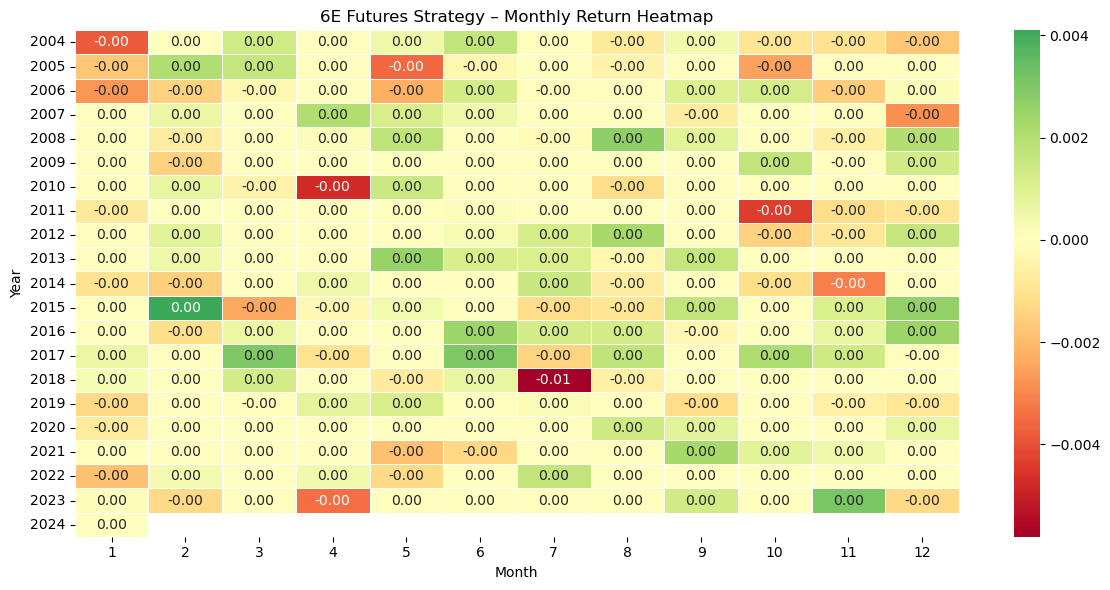

In [40]:
import seaborn as sns

df_6e['year'] = df_6e.index.year
df_6e['month'] = df_6e.index.month
df_6e['monthly_return'] = df_6e['strategy_returns']

monthly_heatmap_6e = df_6e.groupby(['year', 'month'])['monthly_return'].sum().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(monthly_heatmap_6e, cmap="RdYlGn", center=0, annot=True, fmt=".2f", linewidths=0.5)
plt.title("6E Futures Strategy – Monthly Return Heatmap")
plt.ylabel("Year")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

# Comparing EUR/USD vs 6E Side-by-Side

### Summary Table

In [44]:
# Create a summary DataFrame
summary_df = pd.DataFrame({
    "Pair": ["EUR/USD Spot", "6E Futures"],
    "Long Signals": [
        df_spot[df_spot['signal'] == 1].shape[0],
        df_6e[df_6e['signal'] == 1].shape[0]
    ],
    "Short Signals": [
        df_spot[df_spot['signal'] == -1].shape[0],
        df_6e[df_6e['signal'] == -1].shape[0]
    ],
    "Total Return (%)": [
        df_spot['equity'].iloc[-1] - 100,
        df_6e['equity'].iloc[-1] - 100
    ],
    "CAGR (%)": [
        (df_spot['equity'].iloc[-1] / 100) ** (1 / (len(df_spot) / 252)) - 1,
        (df_6e['equity'].iloc[-1] / 100) ** (1 / (len(df_6e) / 252)) - 1
    ],
    "Sharpe Ratio": [
        df_spot['strategy_returns'].mean() / df_spot['strategy_returns'].std() * (252**0.5),
        df_6e['strategy_returns'].mean() / df_6e['strategy_returns'].std() * (252**0.5)
    ],
    "Max Drawdown (%)": [
        (df_spot['equity'].cummax() - df_spot['equity']).max(),
        (df_6e['equity'].cummax() - df_6e['equity']).max()
    ]
})

# Set pair names as index
summary_df.set_index("Pair", inplace=True)

# Display with float formatting (modern and clean)
summary_df.style.format({
    "Total Return (%)": "{:.2f}",
    "CAGR (%)": "{:.2%}",
    "Sharpe Ratio": "{:.2f}",
    "Max Drawdown (%)": "{:.2f}",
})


,Long Signals,Short Signals,Total Return (%),CAGR (%),Sharpe Ratio,Max Drawdown (%)
Pair,,,,,,
EUR/USD Spot,89,95,-8.72,-0.44%,-0.29,15.66
6E Futures,82,88,0.32,0.02%,0.04,1.69


### Final Equity Curve Comparison Chart

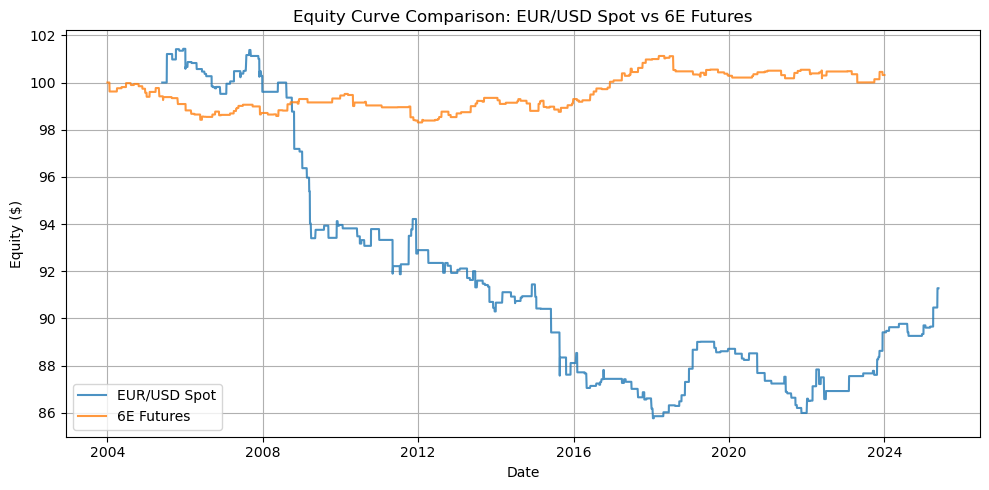

In [47]:
plt.figure(figsize=(10, 5))
plt.plot(df_spot.index, df_spot['equity'], label='EUR/USD Spot', alpha=0.8)
plt.plot(df_6e.index, df_6e['equity'], label='6E Futures', alpha=0.8)
plt.title("Equity Curve Comparison: EUR/USD Spot vs 6E Futures")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# 🧾 Conclusion


- The strategy captured mean-reversion opportunities better in 6E Futures than in Spot.
- Lower drawdown and slightly positive returns on 6E despite similar signal logic.
- Bollinger Band tuning and signal slope filtering made a noticeable impact.
- Future improvements may involve regime filtering (e.g., interest rate changes, macro triggers) or position sizing logic.


## 🧮 Options Strategy Execution Based on Mean Reversion Signal

We now extend the backtest to simulate theoretical bull call and bear put spreads based on the existing mean-reversion signal applied to 6E futures.


In [52]:
from engine.options_signal_runner import run_option_strategy

# Run options strategy based on 6E signal
df_options = run_option_strategy(df_6e)

# Preview result
df_options.head()


,date,spot,signal,K1,K2,net_premium
0,2004-01-20,1.203760,1.0,1.2038,1.2278,0.013470
1,2004-01-21,1.200310,1.0,1.2003,1.2243,0.013431
2,2004-03-30,1.175507,1.0,1.1755,1.1990,0.013153
3,2004-05-13,1.178575,1.0,1.1786,1.2021,0.013188
4,2004-06-24,1.186319,-1.0,1.1626,1.1863,0.013511


### P&L at expiry for each spread

We’ll assume a fixed holding period (e.g., 21 trading days) and simulate expiry spot price.

In [56]:
# Shift spot price to simulate expiry
df_options['expiry_spot'] = df_options['spot'].shift(-21)

# Compute P&L at expiry (spread payoff - net premium)
def compute_spread_pnl(row):
    if row['signal'] == 1:  # Bull Call Spread
        intrinsic = max(0, min(row['expiry_spot'], row['K2']) - row['K1'])
    elif row['signal'] == -1:  # Bear Put Spread
        intrinsic = max(0, row['K2'] - max(row['expiry_spot'], row['K1']))
    else:
        return 0  # no trade

    return intrinsic - row['net_premium']

df_options['pnl'] = df_options.apply(compute_spread_pnl, axis=1)


### Equity curve simulation

In [62]:
# Replace NaNs (final rows with no expiry) with 0
df_options['pnl'] = df_options['pnl'].fillna(0)

# Assume starting capital = 100
df_options['equity'] = 100 + df_options['pnl'].cumsum()


### Plot the equity curve

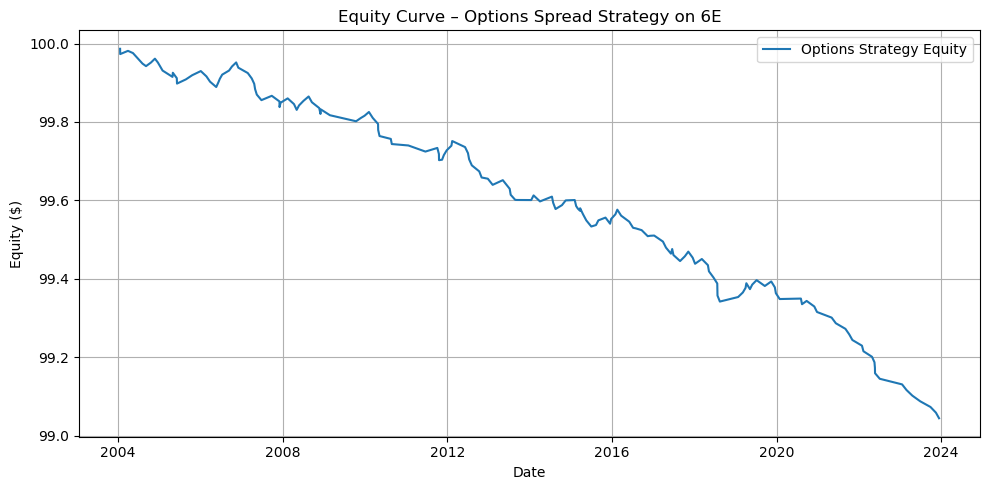

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_options['date'], df_options['equity'], label='Options Strategy Equity')
plt.title("Equity Curve – Options Spread Strategy on 6E")
plt.xlabel("Date")
plt.ylabel("Equity ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [66]:
# 1. Basic Metrics
total_return = df_options['equity'].iloc[-1] - 100
cagr = (df_options['equity'].iloc[-1] / 100) ** (1 / (len(df_options) / 252)) - 1
sharpe = df_options['pnl'].mean() / df_options['pnl'].std() * (252**0.5)
max_dd = (df_options['equity'].cummax() - df_options['equity']).max()

# 2. Display
print(f"📉 Options Spread Strategy Performance on 6E")
print(f"• Total Return: {total_return:.2f}%")
print(f"• CAGR: {cagr:.2%}")
print(f"• Sharpe Ratio: {sharpe:.2f}")
print(f"• Max Drawdown: {max_dd:.2f}%")


📉 Options Spread Strategy Performance on 6E
• Total Return: -0.96%
• CAGR: -1.41%
• Sharpe Ratio: -7.76
• Max Drawdown: 0.94%


## 📈 Options Spread Strategy Summary (6E Futures)

| Metric         | Value         |
|----------------|---------------|
| Total Return   | -0.96%        |
| CAGR           | -1.41%        |
| Sharpe Ratio   | -7.76         |
| Max Drawdown   | 0.94%         |
